# Synthetic Dataset


Import libraries


In [5]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from custom_lstm.utils import ew_acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc

In [6]:
OUTPUT_FILE = "../../data/preprocessed/synthetic_dataset_lag_simple.csv"

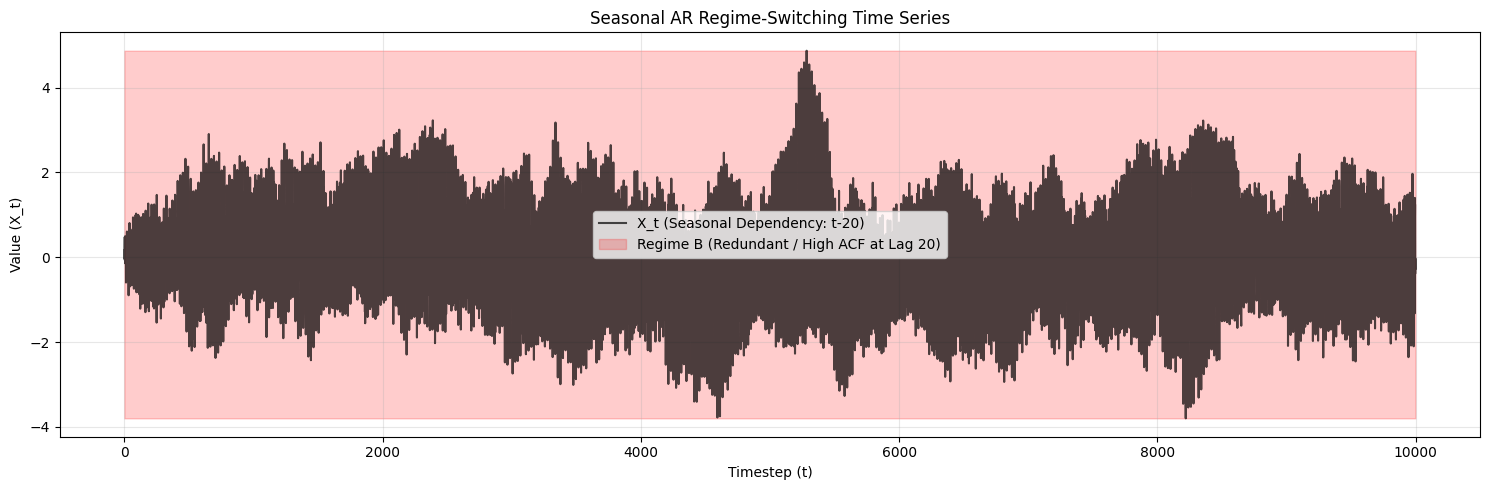

In [10]:
def generate_seasonal_regime_switching_series(
    total_steps: int = 10000,
    regime_duration: int = 10000,
    lag: int = 20,
    ar_coeff_redundant: float = 0.99,
    ar_coeff_noise: float = 0.01,
    target_std: float = 1.0,
    seed: int = 42,
) -> pd.DataFrame:
    """
    Generates a variance-normalized time series alternating between deep seasonal
    autocorrelation (requiring cell state memory) and pure white noise.

    Parameters:
    -----------
    total_steps : int
        Total length of the generated time series.
    regime_duration : int
        The number of timesteps before switching to the alternate regime.
    lag : int
        The temporal distance (L) required to predict the current step.
    ar_coeff_redundant : float
        The Seasonal AR coefficient for Regime B. Should be close to 1.
    ar_coeff_noise : float
        The Seasonal AR coefficient for Regime A. Must be 0 (pure noise).
    target_std : float
        The target standard deviation to maintain across all regimes.
    seed : int
        Random seed for reproducibility.

    Returns:
    --------
    pd.DataFrame containing 'value' (X_t) and 'is_redundant' (Boolean mask).
    """
    np.random.seed(seed)

    # Initialize arrays
    X = np.zeros(total_steps)

    # Determine the phi coefficient for each timestep beforehand
    regime_wave = (np.arange(total_steps) // regime_duration) % 2
    phi_t = np.where(regime_wave == 1, ar_coeff_noise, ar_coeff_redundant)
    is_redundant = regime_wave  # Ground truth mask

    scale_factor = np.sqrt(1 - phi_t**2)
    epsilon = np.random.normal(0, target_std, total_steps) * scale_factor

    X[:lag] = epsilon[:lag]

    for t in range(lag, total_steps):
        X[t] = (phi_t[t] * X[t - lag]) + epsilon[t]

    df = pd.DataFrame({"value": X, "is_redundant": is_redundant})
    return df


if __name__ == "__main__":
    L = 20

    synthetic_data = generate_seasonal_regime_switching_series(total_steps=10000, regime_duration=10000, lag=L, ar_coeff_redundant=0.95, ar_coeff_noise=0.01)

    # Visual verification
    plt.figure(figsize=(15, 5))
    plt.plot(synthetic_data["value"], label=f"X_t (Seasonal Dependency: t-{L})", color="black", alpha=0.7)

    # Highlight the redundant regimes
    plt.fill_between(
        synthetic_data.index,
        synthetic_data["value"].min(),
        synthetic_data["value"].max(),
        where=(synthetic_data["is_redundant"] == 0),
        color="red",
        alpha=0.2,
        label=f"Regime B (Redundant / High ACF at Lag {L})",
    )
    plt.title("Seasonal AR Regime-Switching Time Series")
    plt.xlabel("Timestep (t)")
    plt.ylabel("Value (X_t)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [11]:
time_series = synthetic_data["value"]
time_series.to_csv(OUTPUT_FILE, index=False)
time_series = time_series.to_numpy()

### EW-ACF

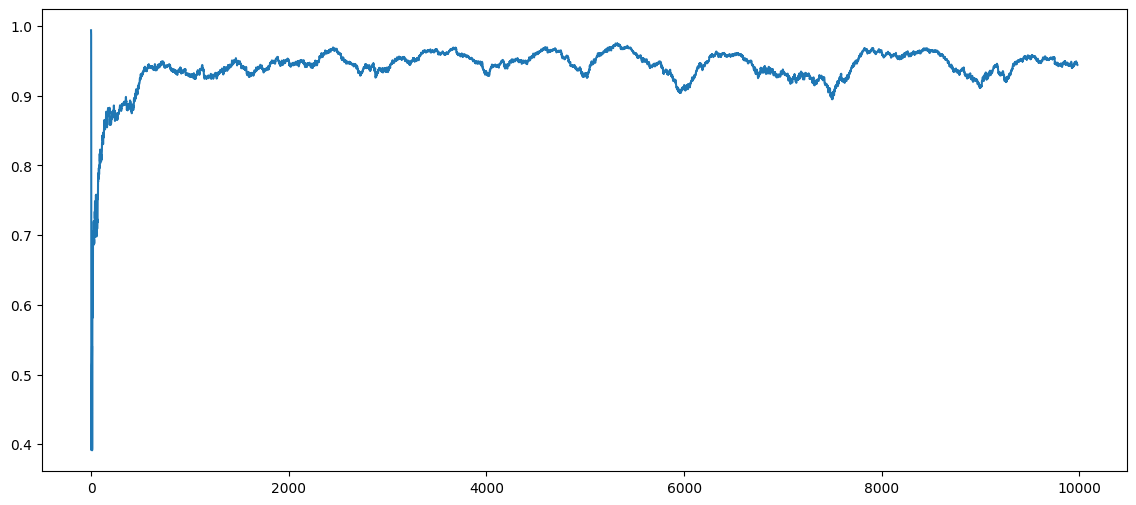

In [12]:
autocorr = ew_acf(time_series, lag=L, lambda_=0.99)
plt.figure(figsize=(14, 6))
plt.plot(autocorr)

### ACF

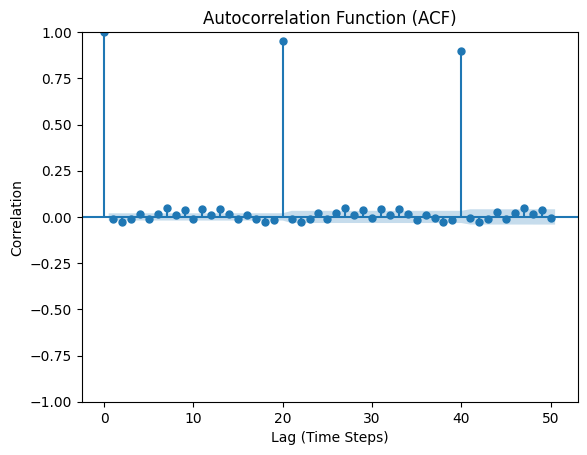

In [13]:
plot_acf(time_series, lags=50, alpha=0.05)
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

### PACF

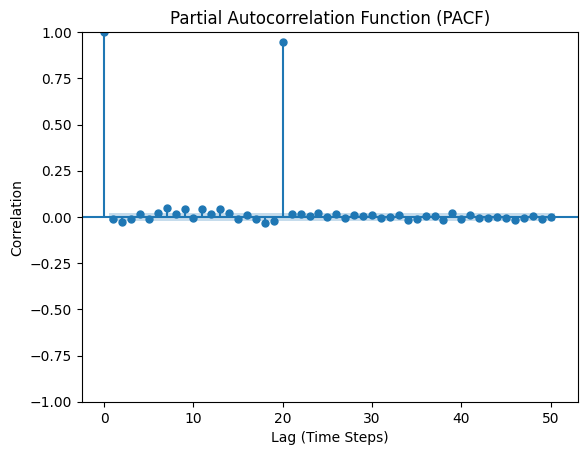

In [14]:
plot_pacf(time_series, lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

## Hurst Exponent


Hurst Exponent (H): 0.8158


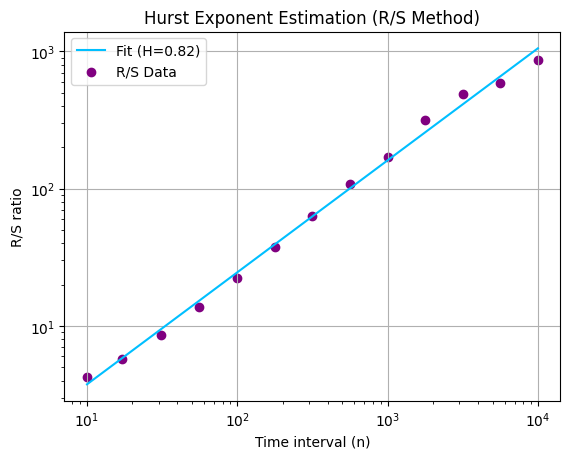

In [15]:
H, c, data = compute_Hc(time_series, kind="change", simplified=True)

print(f"Hurst Exponent (H): {H:.4f}")
f, ax = plt.subplots()
ax.plot(data[0], c * data[0] ** H, color="deepskyblue", label=f"Fit (H={H:.2f})")
ax.scatter(data[0], data[1], color="purple", label="R/S Data")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time interval (n)")
ax.set_ylabel("R/S ratio")
ax.legend()
plt.title("Hurst Exponent Estimation (R/S Method)")
plt.grid(True)
plt.show()